### Background of calculation
Dispersion relation on 1D discrete grid:
\begin{align}
c_t &= \frac{\hbar^2}{2 \, m_e \, dx}\\
E_{e} &= 2 \, c_t \, (1-\cos(k_e \, dx))
\end{align}
The connection between the wavenumber of the electron ($\lambda_e$) and the wavelength reads:
\begin{align}
k_e &= \frac{2 \pi}{\lambda_e} 
\end{align}
Lets note the number of the points under one $\lambda_e$ with $n_l$ thus $\lambda_e=n_l*dx$.
\begin{align}
E_{e} &= 2 \, c_t \, \left(1-\cos\left(\frac{2 \pi}{n_l}\right)\right)\\
c_t &= \frac{E_{e}}{2 \, \left(1-\cos\left(\frac{2 \pi}{n_l}\right)\right)}
\end{align}

In [1]:
# Fixed parameters for the optimization
dx=0.025 # Grid step size in the unit system
emax=5 # Maximum electron energy in eV
npx = 16*1024

# Desired parameters
desired_points_in_lamda = 20
desired_width = 1600

In [2]:
from atomic_units.optimizer import optimize_atomic_units

# Perform optimization
result = optimize_atomic_units(dx, emax, desired_points_in_lamda, desired_width)
print("Optimized parameters:", result['optimized_parameters'])
print("Objective function value:", result['objective_value'])

Optimized parameters: [  3.18125145 158.50443139   1.21580882   2.39380864]
Objective function value: 1.6724758211217639e-12


In [3]:
import atomic_units as au

hb=3.2
e0=2.4
m0=160.0
kappa0=1.2 # 4*pi*epsilon0
dx=0.025

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))
print(dx*unit_sys.length_unit.to('nm'))

0.007297352569307099 dimensionless
0.07558718401663465 electron_volt
3.9688290817798304 nanometer
0.09922072704449576 nanometer


# Set unified grid

In [4]:
import numpy as np

uxgrid_num = 16*1024
uxgrid_dx = dx
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
0.025
409.6
1625.6323918970186 nanometer


In [5]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.Dispersion(uxgrid_dx, hbar = unit_sys.hb,\
                            mass = unit_sys.me)

2.4178695952691127
41
[-48.35739191 -45.93952231 -43.52165271 -41.10378312 -38.68591352
 -36.26804393 -33.85017433 -31.43230474 -29.01443514 -26.59656555
 -24.17869595 -21.76082636 -19.34295676 -16.92508717 -14.50721757
 -12.08934798  -9.67147838  -7.25360879  -4.83573919  -2.4178696
   0.           2.4178696    4.83573919   7.25360879   9.67147838
  12.08934798  14.50721757  16.92508717  19.34295676  21.76082636
  24.17869595  26.59656555  29.01443514  31.43230474  33.85017433
  36.26804393  38.68591352  41.10378312  43.52165271  45.93952231
  48.35739191]


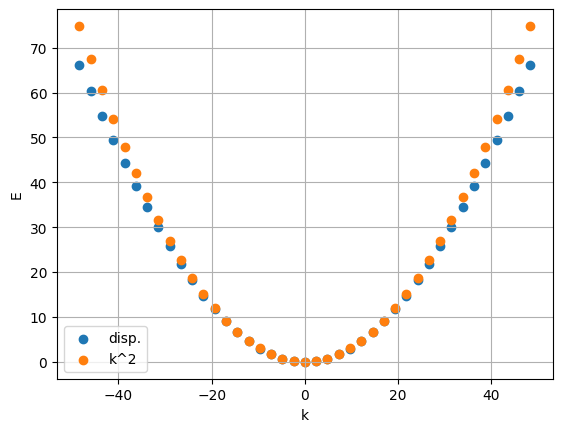

In [7]:
import matplotlib.pyplot as plt

emax_in_unit_sys = emax*unit_sys.convert_energy_from("eV")
k_max = dispersion.energy2k(1.0*emax_in_unit_sys)

ukgrid_max = k_max
ukgrid_min = -k_max
ukgrid_num = 41

ukgrid, ukgrid_dx = np.linspace(ukgrid_min, ukgrid_max,\
                               ukgrid_num,retstep=True)

print(ukgrid_dx)
print(ukgrid_num)
print(ukgrid)

plt.scatter(ukgrid,dispersion.k2energy(ukgrid),label="disp.")
plt.scatter(ukgrid,((unit_sys.hb**2)/(2*unit_sys.me))*ukgrid**2,label="k^2")
plt.xlabel("k")
plt.ylabel("E")
plt.legend()
plt.grid()
plt.show()

In [8]:


print(k_max)
lambda_min = 2*np.pi/k_max
print(lambda_min)
num_of_points_in_lambda = 2*lambda_min/uxgrid_dx
print(num_of_points_in_lambda)

48.35739190538226
0.12993226184475548
10.394580947580438
